<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 700px;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h1 style="font-size: 48px; margin-bottom: 20px; text-transform: letter-spacing: 2px; color: #87CEEB;"><strong>Jose Carlos Fernandez</strong><h1>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Fecha:</strong> 17 de Julio de 2025</p>
    <p style="font-size: 22px; margin: 10px 0;"><strong>Maestro:</strong> Persio Martinez</p>
</div>

<div style="
    font-family: 'Poppins', sans-serif;
    background: linear-gradient(135deg, #001f3f, #003366);
    color: white;
    width: 50%;
    padding: 30px;
    border-radius: 15px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
    border: 2px solid #00509e;
">
    <h2 style="font-size: 28px; margin-bottom: 15px; color: #87CEEB;"><strong>Segundo Parcial</strong></h2>
    <p style="font-size: 18px; margin: 10px 0; font-weight: 500; color: #f0f8ff;">
        Base de Datos 2.
    </p>
</div>

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **📚 Objetivo 0️⃣: Importacion de las librerias necesarias**

In [7]:
import pyodbc # Para conectarse a SQL Server
import numpy as np # Para manejar NaN y NaT
import pandas as pd 
from pymongo import MongoClient # Para conectarse a MongoDB

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **🗃️ Objetivo 1️⃣: Consulta y Migración de Datos desde SQL Server a MongoDB**


> **👉 Primero, debemos traer nuestros datos de SQL Server, para luego enviarlos a MongoDB**

In [ ]:
# Conexion a SQL Server
conn = pyodbc.connect('DRIVER={SQL Server};SERVER=JOSECARLOS\SQLEXPRESS01;DATABASE=AdventureWorks2019;Trusted_Connection=yes;')
query = "SELECT * FROM Production.Product"  # Query para obtener datos de la tabla de  Production.Product, que es la que me toco

# Ponemos la tabla en un DataFrame
df = pd.read_sql(query, conn)

df.head()  # Mostramos las primeras filas del DataFrame para verificar la carga

C:\Users\josecarlos\AppData\Local\Temp\ipykernel_12792\2640100346.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,...,ProductLine,Class,Style,ProductSubcategoryID,ProductModelID,SellStartDate,SellEndDate,DiscontinuedDate,rowguid,ModifiedDate
0,1,Adjustable Race,AR-5381,False,False,None,1000,750,0.0,0.0,...,None,None,None,NaN,NaN,2008-04-30,NaT,None,694215B7-08F7-4C0D-ACB1-D734BA44C0C8,2014-02-08 10:01:36.827
1,2,Bearing Ball,BA-8327,False,False,None,1000,750,0.0,0.0,...,None,None,None,NaN,NaN,2008-04-30,NaT,None,58AE3C20-4F3A-4749-A7D4-D568806CC537,2014-02-08 10:01:36.827
2,3,BB Ball Bearing,BE-2349,True,False,None,800,600,0.0,0.0,...,None,None,None,NaN,NaN,2008-04-30,NaT,None,9C21AED2-5BFA-4F18-BCB8-F11638DC2E4E,2014-02-08 10:01:36.827
3,4,Headset Ball Bearings,BE-2908,False,False,None,800,600,0.0,0.0,...,None,None,None,NaN,NaN,2008-04-30,NaT,None,ECFED6CB-51FF-49B5-B06C-7D8AC834DB8B,2014-02-08 10:01:36.827
4,316,Blade,BL-2036,True,False,None,800,600,0.0,0.0,...,None,None,None,NaN,NaN,2008-04-30,NaT,None,E73E9750-603B-4131-89F5-3DD15ED5FF80,2014-02-08 10:01:36.827


> **Ok☑️, entonces ahora nos debemos conectar a MongoDB y subir los datos extraidos**

**Tomando en cuenta:**

- 🍃 Montar la tabla en una base de datos llamada `Parcial2` 🍃

In [ ]:
# Conexion a MongoDB
client = MongoClient("mongodb://localhost:27017/") 
db = client["Parcial2"]
collection = db["Production.Prodcut"]  # Nombre la coleccion igual al de la tabla en SQL Server

# Convertimos los registros NaT y NaN a None en todo el DataFrame para evitar problemas al insertar en MongoDB
df = df.replace({pd.NaT: None, np.nan: None})

# Bucle para convertir NaT a None en columnas datetime, esto es necesario porque MongoDB no maneja NaT
for col in df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]):
    df[col] = df[col].apply(lambda x: x if pd.notnull(x) else None)


collection.insert_many(df.to_dict("records"))

InsertManyResult([ObjectId('6879cee5a7b918fe8985fe7a'), ObjectId('6879cee5a7b918fe8985fe7b'), ObjectId('6879cee5a7b918fe8985fe7c'), ObjectId('6879cee5a7b918fe8985fe7d'), ObjectId('6879cee5a7b918fe8985fe7e'), ObjectId('6879cee5a7b918fe8985fe7f'), ObjectId('6879cee5a7b918fe8985fe80'), ObjectId('6879cee5a7b918fe8985fe81'), ObjectId('6879cee5a7b918fe8985fe82'), ObjectId('6879cee5a7b918fe8985fe83'), ObjectId('6879cee5a7b918fe8985fe84'), ObjectId('6879cee5a7b918fe8985fe85'), ObjectId('6879cee5a7b918fe8985fe86'), ObjectId('6879cee5a7b918fe8985fe87'), ObjectId('6879cee5a7b918fe8985fe88'), ObjectId('6879cee5a7b918fe8985fe89'), ObjectId('6879cee5a7b918fe8985fe8a'), ObjectId('6879cee5a7b918fe8985fe8b'), ObjectId('6879cee5a7b918fe8985fe8c'), ObjectId('6879cee5a7b918fe8985fe8d'), ObjectId('6879cee5a7b918fe8985fe8e'), ObjectId('6879cee5a7b918fe8985fe8f'), ObjectId('6879cee5a7b918fe8985fe90'), ObjectId('6879cee5a7b918fe8985fe91'), ObjectId('6879cee5a7b918fe8985fe92'), ObjectId('6879cee5a7b918fe8985fe

**`records` hace que cada fila del DataFrame se convierta en un diccionario, donde las claves son los nombres de las columnas y los valores son los datos de esa fila.**

> El resultado es una lista de diccionarios, lista para insertar en MongoDB como documentos.

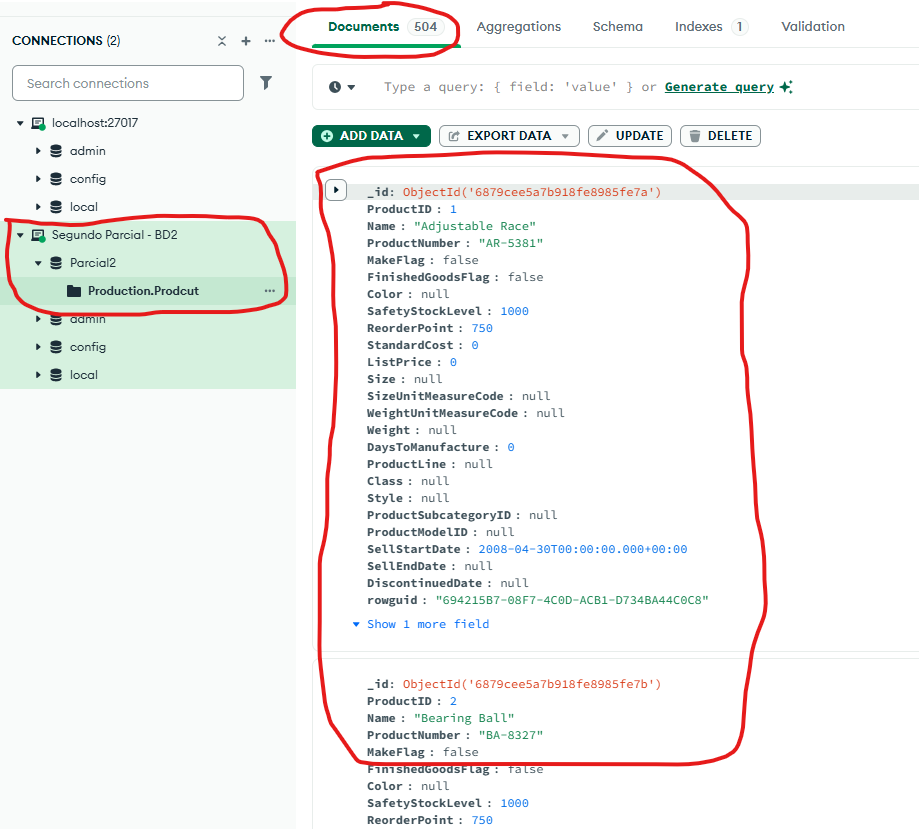

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **➕ Objetivo 2️⃣: Insertar Documentos en MongoDB**


> **Agregaremos 2️⃣ documentos nuevos a nuestra coleccion, obviamente respetando la estructura de datos**

In [ ]:
# Por `respetar la estructura de datos` me refiero a agregar las mismas claves (columnas) que ya existen en la coleccion
nuevos_docs = [
    {
        "ProductID": 1001,
        "Name": "Producto Parcial 1",
        "ProductNumber": "PD-1001",
        "MakeFlag": True,
        "FinishedGoodsFlag": False,
        "Color": "Red",
        "SafetyStockLevel": 500,
        "ReorderPoint": 300,
        "StandardCost": 10.5,
        "ListPrice": 20.0,
        "Size": None,
        "SizeUnitMeasureCode": None,
        "WeightUnitMeasureCode": None,
        "Weight": None,
        "DaysToManufacture": 2,
        "ProductLine": None,
        "Class": None,
        "Style": None,
        "ProductSubcategoryID": None,
        "ProductModelID": None,
        "SellStartDate": "2025-07-17",
        "SellEndDate": None,
        "DiscontinuedDate": None,
        "rowguid": "00000000-0000-0000-0000-000000000001",
        "ModifiedDate": "2025-07-17 10:00:00"
    },
    {
        "ProductID": 1002,
        "Name": "Producto Parcial 2",
        "ProductNumber": "PD-1002",
        "MakeFlag": False,
        "FinishedGoodsFlag": True,
        "Color": "Blue",
        "SafetyStockLevel": 600,
        "ReorderPoint": 350,
        "StandardCost": 12.0,
        "ListPrice": 22.0,
        "Size": None,
        "SizeUnitMeasureCode": None,
        "WeightUnitMeasureCode": None,
        "Weight": None,
        "DaysToManufacture": 3,
        "ProductLine": None,
        "Class": None,
        "Style": None,
        "ProductSubcategoryID": None,
        "ProductModelID": None,
        "SellStartDate": "2025-07-17",
        "SellEndDate": None,
        "DiscontinuedDate": None,
        "rowguid": "00000000-0000-0000-0000-000000000002",
        "ModifiedDate": "2025-07-17 10:00:00"
    }
]

collection.insert_many(nuevos_docs)

InsertManyResult([ObjectId('6879d235a7b918fe89860072'), ObjectId('6879d235a7b918fe89860073')], acknowledged=True)

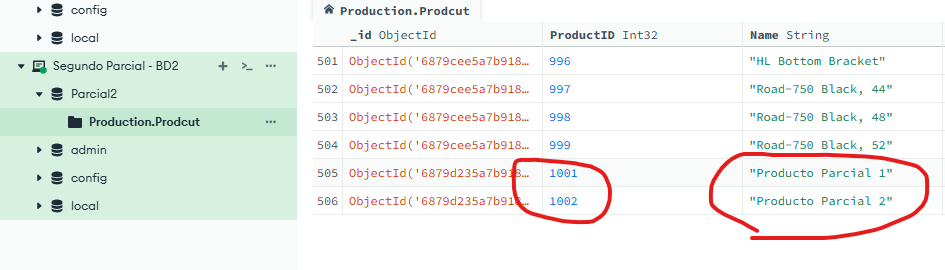

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **🔍 Objetivo 3️⃣: Consultas Específicas (find) en MongoDB**


> **Consulta 1️⃣: productos cuyo ListPrice sea mayor a 20**

In [15]:
resultado1 = collection.find({"ListPrice": {"$gt": 20}}) # Aqui buscamos los productos cuyo ListPrice sea mayor a 20

df_resultado1 = pd.DataFrame(list(resultado1)) # Convertimos el resultado a un DataFrame para que se vea mas bonito

df_resultado1[["ProductID", "Name", "ListPrice"]]  # Mostramos solo las columnas ProductID, Name y ListPrice para que se vea mas limpio

C:\Users\josecarlos\AppData\Local\Temp\ipykernel_12792\1707298491.py:3: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  df_resultado1 = pd.DataFrame(list(resultado1)) # Convertimos el resultado a un DataFrame para que se vea mas bonito


,ProductID,Name,ListPrice
0,514,LL Mountain Seat Assembly,133.34
1,515,ML Mountain Seat Assembly,147.14
2,516,HL Mountain Seat Assembly,196.92
3,517,LL Road Seat Assembly,133.34
4,518,ML Road Seat Assembly,147.14
...,...,...,...
285,996,HL Bottom Bracket,121.49
286,997,"Road-750 Black, 44",539.99
287,998,"Road-750 Black, 48",539.99
288,999,"Road-750 Black, 52",539.99


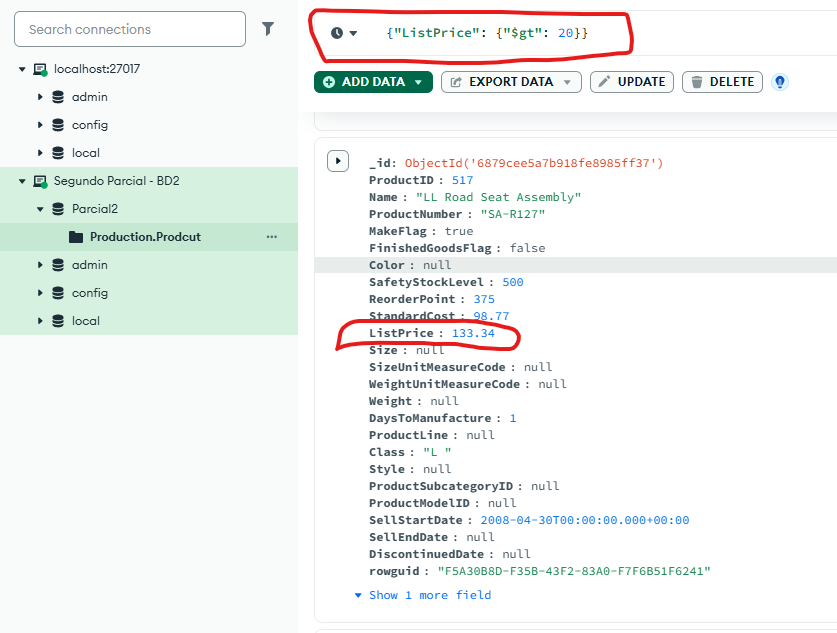

> **Consulta 2️⃣: productos cuyo Color sea Blue**

In [16]:
resultado2 = collection.find({"Color": "Blue"}) # Buscamos productos cuyo Color sea Blue

df_resultado2 = pd.DataFrame(list(resultado2)) # Convertimos el resultado a un DataFrame para que se vea mas bonito (otra vez 😅)

df_resultado2[["ProductID", "Name", "Color"]]  # Mostramos solo las columnas ProductID, Name y Color para que se vea mas limpio (otra vez 😅)

C:\Users\josecarlos\AppData\Local\Temp\ipykernel_12792\970357577.py:3: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  df_resultado2 = pd.DataFrame(list(resultado2)) # Convertimos el resultado a un DataFrame para que se vea mas bonito (otra vez 😅)


,ProductID,Name,Color
0,711,"Sport-100 Helmet, Blue",Blue
1,864,"Classic Vest, S",Blue
2,865,"Classic Vest, M",Blue
3,866,"Classic Vest, L",Blue
4,890,"HL Touring Frame - Blue, 46",Blue
5,891,"HL Touring Frame - Blue, 50",Blue
6,892,"HL Touring Frame - Blue, 54",Blue
7,893,"HL Touring Frame - Blue, 60",Blue
8,895,"LL Touring Frame - Blue, 50",Blue
9,896,"LL Touring Frame - Blue, 54",Blue


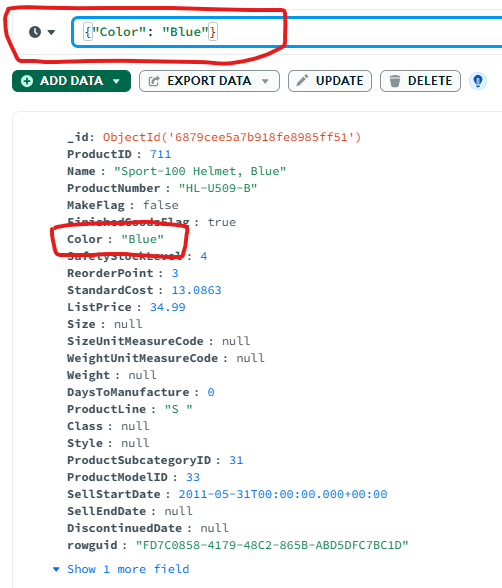

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **✏️ Objetivo 4️⃣: Actualización (update) de Documentos en MongoDB**


In [17]:
# Actualizaremos el ListPrice de los productos que acabamos de insertar 

collection.update_one({"ProductID": 1001}, {"$set": {"ListPrice": 999}})
collection.update_one({"ProductID": 1002}, {"$set": {"ListPrice": 888}})


# =======🔵 Mostrmos los resultados 🔵===========

resultado = collection.find({"ProductID": {"$in": [1001, 1002]}})  # Consulta para verificar los cambios
df_resultado = pd.DataFrame(list(resultado))  # Convertimos los resultados a un DataFrame
df_resultado[["ProductID", "Name", "ListPrice"]]  # Mostramos solo las columnas ProductID, Name y ListPrice para que se vea mas limpio

,ProductID,Name,ListPrice
0,1001,Producto Parcial 1,999
1,1002,Producto Parcial 2,888


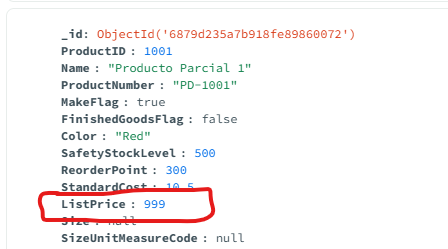
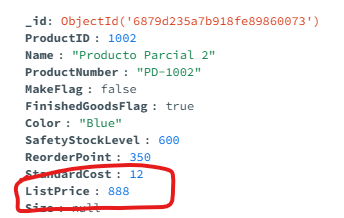

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

# **🗑️ Objetivo 5️⃣: Eliminación (delete) de Documentos en MongoDB**

In [19]:
# Vamos a eliminar los documentos que acabamos de insertar para limpiar la base de datos
# El primero tiene ProductID 1001 y el segundo tiene ListPrice 888

collection.delete_one({"ProductID": 1001})
collection.delete_one({"ListPrice": 888})

DeleteResult({'n': 0, 'ok': 1.0}, acknowledged=True)

> **Antes: 🔵**

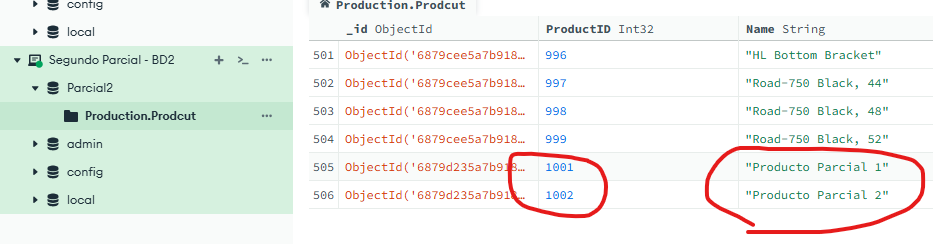

> **Despues: 🔴**

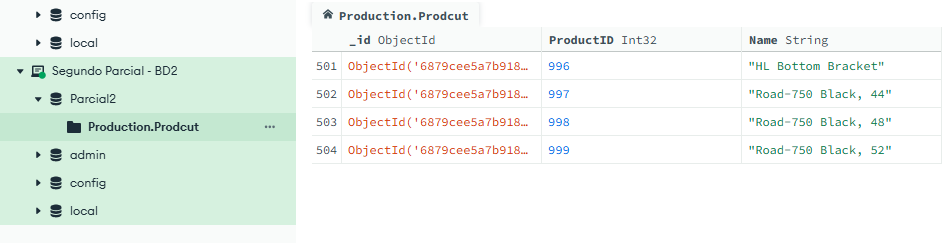

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background: linear-gradient(135deg, #28a745, #218838); color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 8px 16px rgba(0, 0, 0, 0.3); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center; border: 4px solid #1e7e34; position: relative;">
        <span style="text-shadow: 2px 2px 8px rgba(0, 0, 0, 0.5);">FIN</span>
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: rgba(255, 255, 255, 0.7); font-style: italic;">Jose Carlos Fernandez</p>
    </div>
</div>